# Restaurant Recommendation System — 01 Exploratory Data Analysis

A **collaborative-filtering** recommender on the UCI *Restaurant & Consumer* dataset. Consumers rated restaurants on a **0–2 scale** (0 = disliked, 2 = liked). We learn from the user × restaurant rating matrix to recommend places each consumer will enjoy.

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
%matplotlib inline
import utils

ratings=utils.load_ratings(); names=utils.load_items()
print('ratings:',ratings.shape,'| users:',ratings.user.nunique(),'| places:',ratings.item.nunique())
ratings.head()

ratings: (1161, 3) | users: 138 | places: 130


,user,item,rating
0,U1077,135085,2
1,U1077,135038,2
2,U1077,132825,2
3,U1077,135060,1
4,U1068,135104,1


## 1. Rating distribution (0–2 scale)

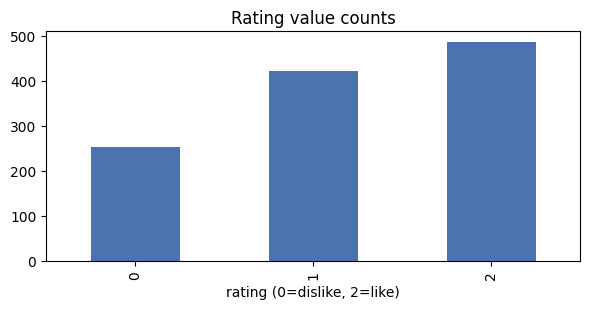

mean rating: 1.2


In [2]:
fig,ax=plt.subplots(figsize=(6,3.2))
ratings['rating'].value_counts().sort_index().plot(kind='bar',ax=ax,color='#4c72b0')
ax.set_title('Rating value counts'); ax.set_xlabel('rating (0=dislike, 2=like)')
plt.tight_layout(); plt.show()
print('mean rating:',round(ratings['rating'].mean(),3))

## 2. Activity per user / per restaurant

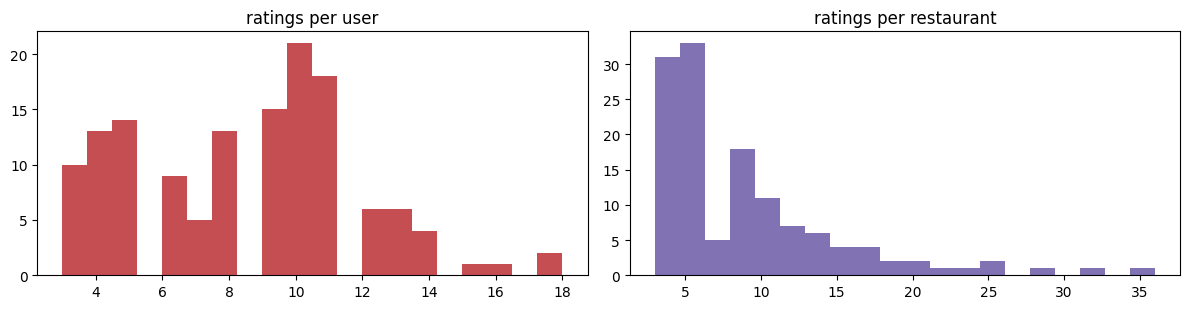

per user: median 9 max 18
per restaurant: median 7 max 36


In [3]:
rpu=ratings.groupby('user').size(); rpp=ratings.groupby('item').size()
fig,ax=plt.subplots(1,2,figsize=(12,3.2))
ax[0].hist(rpu,bins=20,color='#c44e52'); ax[0].set_title('ratings per user')
ax[1].hist(rpp,bins=20,color='#8172b3'); ax[1].set_title('ratings per restaurant')
plt.tight_layout(); plt.show()
print('per user: median %d max %d'%(rpu.median(),rpu.max())); print('per restaurant: median %d max %d'%(rpp.median(),rpp.max()))

## 3. Sparsity

In [4]:
nu,ni=ratings.user.nunique(),ratings.item.nunique()
d=len(ratings)/(nu*ni)
print(f'{nu} users x {ni} restaurants = {nu*ni:,} cells; {len(ratings):,} ratings')
print('density: %.2f%% (sparsity %.2f%%)'%(100*d,100*(1-d)))

138 users x 130 restaurants = 17,940 cells; 1,161 ratings
density: 6.47% (sparsity 93.53%)


## 4. Best-liked restaurants (>=10 ratings)

In [5]:
agg=ratings.groupby('item')['rating'].agg(['mean','count']); agg['name']=agg.index.map(names)
print(agg[agg['count']>=10].sort_values('mean',ascending=False).head(8)[['name','count','mean']].to_string())

                              name  count      mean
item                                               
135075        Mariscos El Pescador     13  1.692308
135025  El Rincon de San Francisco     15  1.666667
132768          Mariscos Tia Licha     10  1.600000
135030    Preambulo Wifi Zone Cafe     12  1.583333
135028                 La Virreina     15  1.533333
135066          Restaurante Guerra     12  1.500000
135045     Restaurante la Gran Via     13  1.461538
132754             Cabana Huasteca     13  1.461538


## 5. Summary

- **138 consumers, 130 restaurants, 1,161 ratings** — small and **~94% sparse**.
- Ratings cluster at the top (mean ≈ 1.2 on 0–2) — consumers report likes more than dislikes.
- Each consumer rated only a handful of places; neighbourhood overlap is thin, so latent-factor models may help. Notebooks 02–03 build the matrix and compare models.